In [3]:
# ── Cellule 1 : Chargement des données ──────────────────────────────────────

from google.colab import drive
import numpy as np

drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/dataset/'

# ── California ───────────────────────────────────────────────────────────────
CA_X       = np.load(DATA_PATH + 'CA_X.npy')        # (N, T, 10)  — S2 time-series
CA_y       = np.load(DATA_PATH + 'CA_y.npy')        # (N,)        — labels
CA_climate = np.load(DATA_PATH + 'CA_climate.npy')  # (N, C_clim)
CA_soil    = np.load(DATA_PATH + 'CA_soil.npy')     # (N, C_soil)
CA_topo    = np.load(DATA_PATH + 'CA_topo.npy')     # (N, C_topo)

# ── Arkansas ─────────────────────────────────────────────────────────────────
AR_X       = np.load(DATA_PATH + 'AR_X.npy')
AR_y       = np.load(DATA_PATH + 'AR_y.npy')
AR_climate = np.load(DATA_PATH + 'AR_climate.npy')
AR_soil    = np.load(DATA_PATH + 'AR_soil.npy')
AR_topo    = np.load(DATA_PATH + 'AR_topo.npy')

# ── Vérification des shapes ──────────────────────────────────────────────────
print("=== California ===")
print(f"  X       : {CA_X.shape}")
print(f"  y       : {CA_y.shape}  | classes : {np.unique(CA_y)}")
print(f"  climate : {CA_climate.shape}")
print(f"  soil    : {CA_soil.shape}")
print(f"  topo    : {CA_topo.shape}")

print("\n=== Arkansas ===")
print(f"  X       : {AR_X.shape}")
print(f"  y       : {AR_y.shape}  | classes : {np.unique(AR_y)}")
print(f"  climate : {AR_climate.shape}")
print(f"  soil    : {AR_soil.shape}")
print(f"  topo    : {AR_topo.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== California ===
  X       : (10000, 36, 10)
  y       : (10000,)  | classes : [  3  36  69  75 204 999]
  climate : (10000, 36, 3)
  soil    : (10000, 3)
  topo    : (10000, 2)

=== Arkansas ===
  X       : (10000, 36, 10)
  y       : (10000,)  | classes : [  1   2   3   5 999]
  climate : (10000, 36, 3)
  soil    : (10000, 3)
  topo    : (10000, 2)


In [14]:
# ── Cellule 2 : Encodage labels + fusion covariables ────────────────────────

from sklearn.preprocessing import LabelEncoder
import numpy as np

def prepare_region(X, y, climate, soil, topo):
    """
    Retourne un dict avec toutes les configurations d'entrée.

    Stratégie de fusion :
      - climate (36, 3)  → temporel  : concaténé sur la dim bandes → (36, 13)
      - soil    (3,)     → statique  : répété sur T → (36, 3) puis concaténé
      - topo    (2,)     → statique  : répété sur T → (36, 2) puis concaténé
    """
    N, T, B = X.shape  # (10000, 36, 10)

    # ── Label encoding ───────────────────────────────────────────────────────
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # ── Expansion des covariables statiques → (N, T, C) ─────────────────────
    soil_exp = np.repeat(soil[:, np.newaxis, :], T, axis=1)   # (N, 36, 3)
    topo_exp = np.repeat(topo[:, np.newaxis, :], T, axis=1)   # (N, 36, 2)

    # ── 5 configurations : concaténation sur l'axe des bandes (axis=2) ───────
    configs = {
        'S2_only'         : X,                                                          # (N,36,10)
        'S2_climate'      : np.concatenate([X, climate],            axis=2),            # (N,36,13)
        'S2_soil'         : np.concatenate([X, soil_exp],           axis=2),            # (N,36,13)
        'S2_topo'         : np.concatenate([X, topo_exp],           axis=2),            # (N,36,12)
        'S2_all'          : np.concatenate([X, climate,
                                            soil_exp, topo_exp],    axis=2),            # (N,36,18)
    }

    return configs, y_enc, le

# ── Application sur les deux régions ────────────────────────────────────────
CA_configs, CA_y_enc, CA_le = prepare_region(CA_X, CA_y, CA_climate, CA_soil, CA_topo)
AR_configs, AR_y_enc, AR_le = prepare_region(AR_X, AR_y, AR_climate, AR_soil, AR_topo)

# ── Vérification ─────────────────────────────────────────────────────────────
print("=== California ===")
print(f"  Classes encodées : {CA_le.classes_} → {list(range(len(CA_le.classes_)))}")
for name, arr in CA_configs.items():
    print(f"  {name:<20} : {arr.shape}")

print("\n=== Arkansas ===")
print(f"  Classes encodées : {AR_le.classes_} → {list(range(len(AR_le.classes_)))}")
for name, arr in AR_configs.items():
    print(f"  {name:<20} : {arr.shape}")

=== California ===
  Classes encodées : [  3  36  69  75 204 999] → [0, 1, 2, 3, 4, 5]
  S2_only              : (10000, 36, 10)
  S2_climate           : (10000, 36, 13)
  S2_soil              : (10000, 36, 13)
  S2_topo              : (10000, 36, 12)
  S2_all               : (10000, 36, 18)

=== Arkansas ===
  Classes encodées : [  1   2   3   5 999] → [0, 1, 2, 3, 4]
  S2_only              : (10000, 36, 10)
  S2_climate           : (10000, 36, 13)
  S2_soil              : (10000, 36, 13)
  S2_topo              : (10000, 36, 12)
  S2_all               : (10000, 36, 18)


In [29]:
BATCH_SIZE   = 128
EPOCHS       = 200
LR           = 0.001
WEIGHT_DECAY = 1e-4
TRAIN_N      = 240
VAL_N        = 60

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16, geo_dim=2):
        super().__init__()
        self.geo_dim  = geo_dim
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        hidden = max(channels // reduction, 4)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels + geo_dim, hidden, bias=False),
            nn.ReLU(),
            nn.Linear(hidden, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, geo=None):
        avg = self.avg_pool(x).squeeze(-1)
        mx  = self.max_pool(x).squeeze(-1)

        if self.geo_dim > 0 and geo is not None:
            avg = torch.cat([avg, geo], dim=-1)
            mx  = torch.cat([mx,  geo], dim=-1)

        scale = self.sigmoid(self.mlp(avg) + self.mlp(mx))
        return x * scale.unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv    = nn.Conv1d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg   = x.mean(dim=1, keepdim=True)
        mx    = x.max(dim=1, keepdim=True)[0]
        scale = self.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * scale


class GeoCBAM(nn.Module):
    def __init__(self, channels, reduction=16, geo_dim=2):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction, geo_dim)
        self.sa = SpatialAttention()

    def forward(self, x, geo=None):
        x = self.ca(x, geo)
        x = self.sa(x)
        return x


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.shortcut = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class GeoCBAMCNN(nn.Module):
    def __init__(self, num_classes, n_bands=10, geo_dim=2, dropout=0.4):
        super().__init__()
        self.geo_dim = geo_dim

        self.entry = nn.Sequential(
            nn.Conv1d(n_bands, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.res1   = ResBlock(64,  64)
        self.cbam1  = GeoCBAM(64,  geo_dim=geo_dim)

        self.res2   = ResBlock(64,  128)
        self.cbam2  = GeoCBAM(128, geo_dim=geo_dim)

        self.res3   = ResBlock(128, 256)
        self.cbam3  = GeoCBAM(256, geo_dim=geo_dim)

        self.gap     = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(p=dropout)
        self.fc      = nn.Linear(256, num_classes)

    def forward(self, x, geo=None):
        # The CropDataset already handles the permute to (N, B, T)
        # So, the input `x` here is already in the correct (batch_size, channels, length) format
        # for Conv1d. The conditional transpose below is incorrect and causes the error.
        # if x.shape[2] != self.entry[0].in_channels:
        #     x = x.transpose(1, 2)

        x = self.entry(x)

        x = self.res1(x)
        x = self.cbam1(x, geo)

        x = self.res2(x)
        x = self.cbam2(x, geo)

        x = self.res3(x)
        x = self.cbam3(x, geo)

        x = self.gap(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)


Device : cuda


In [31]:
# ── Cellule 3 : Dataset + Splits + Loaders ──────────────────────────────────

class CropDataset(Dataset):
    def __init__(self, pixels, labels_enc):
        X = torch.tensor(pixels / 10000.0, dtype=torch.float32)
        self.X = X.permute(0, 2, 1)          # (N,T,B) → (N,B,T)
        self.y = torch.tensor(labels_enc, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_splits(labels_enc, train_n=TRAIN_N, val_n=VAL_N, seed=42):
    np.random.seed(seed)
    idx_tr, idx_val, idx_te = [], [], []
    for c in np.unique(labels_enc):
        idx = np.where(labels_enc == c)[0]
        np.random.shuffle(idx)
        tr = min(train_n, len(idx))
        v  = min(val_n,   len(idx) - tr)
        idx_tr .extend(idx[:tr])
        idx_val.extend(idx[tr:tr + v])
        idx_te .extend(idx[tr + v:])
    return np.array(idx_tr), np.array(idx_val), np.array(idx_te)


def make_loaders(X, y_enc, batch_size=BATCH_SIZE):
    idx_tr, idx_val, idx_te = make_splits(y_enc)
    tr_loader  = DataLoader(CropDataset(X[idx_tr],  y_enc[idx_tr]),  batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(CropDataset(X[idx_val], y_enc[idx_val]), batch_size=batch_size)
    te_loader  = DataLoader(CropDataset(X[idx_te],  y_enc[idx_te]),  batch_size=batch_size)
    print(f"  Train: {len(idx_tr)} | Val: {len(idx_val)} | Test: {len(idx_te)}")
    return tr_loader, val_loader, te_loader


# ── Test rapide ───────────────────────────────────────────────────────────────
tr_loader, val_loader, te_loader = make_loaders(CA_configs['S2_only'], CA_y_enc)
X_b, y_b = next(iter(tr_loader))
print(f"  Batch shape: {X_b.shape}  → attendu (128, 10, 36) ✓")

  Train: 1440 | Val: 360 | Test: 8200
  Batch shape: torch.Size([128, 10, 36])  → attendu (128, 10, 36) ✓


In [32]:
# ── Cellule 5 : Ablation study ───────────────────────────────────────────────

BAND_DIMS = {
    'S2_only'    : 10,
    'S2_climate' : 13,
    'S2_soil'    : 13,
    'S2_topo'    : 12,
    'S2_all'     : 18,
}

results = {}

for region_name, configs, y_enc, le in [
        ('CA', CA_configs, CA_y_enc, CA_le),
        ('AR', AR_configs, AR_y_enc, AR_le),
]:
    num_classes = len(le.classes_)
    results[region_name] = {}

    for cfg_name, X in configs.items():
        print(f"\n{'='*55}")
        print(f"  {region_name}  |  {cfg_name}  |  n_bands={BAND_DIMS[cfg_name]}  |  classes={num_classes}")
        print(f"{'='*55}")

        tr_loader, val_loader, te_loader = make_loaders(X, y_enc)

        model = GeoCBAMCNN(
            num_classes = num_classes,
            n_bands     = BAND_DIMS[cfg_name],
            dropout     = 0.4,
            geo_dim     = 0, # Fix: Set geo_dim to 0 as no separate 'geo' input is provided
        ).to(device)

        history = run(model, tr_loader, val_loader)

        oa, kappa, f1, y_pred, y_true = evaluate(model, te_loader)
        print(f"\n  ✅ TEST  OA={oa:.2f}%  Kappa={kappa:.2f}%  F1={f1:.2f}%")

        results[region_name][cfg_name] = {
            'oa': oa, 'kappa': kappa, 'f1': f1,
            'history': history,
            'y_pred': y_pred, 'y_true': y_true,
        }



  CA  |  S2_only  |  n_bands=10  |  classes=6
  Train: 1440 | Val: 360 | Test: 8200
  Epoch  20/200  loss=0.3732  val OA=65.56%  Kappa=58.67%  F1=62.59%
  Epoch  40/200  loss=0.1718  val OA=77.22%  Kappa=72.67%  F1=77.16%
  Epoch  60/200  loss=0.1655  val OA=76.94%  Kappa=72.33%  F1=77.23%
  Epoch  80/200  loss=0.1427  val OA=78.33%  Kappa=74.00%  F1=78.48%
  Epoch 100/200  loss=0.1380  val OA=77.78%  Kappa=73.33%  F1=77.79%
  Epoch 120/200  loss=0.1457  val OA=76.94%  Kappa=72.33%  F1=76.79%
  Epoch 140/200  loss=0.1318  val OA=76.67%  Kappa=72.00%  F1=76.49%
  Epoch 160/200  loss=0.1375  val OA=78.33%  Kappa=74.00%  F1=78.34%
  Epoch 180/200  loss=0.1308  val OA=78.61%  Kappa=74.33%  F1=78.68%
  Epoch 200/200  loss=0.1300  val OA=78.33%  Kappa=74.00%  F1=78.36%

  ✅ TEST  OA=75.44%  Kappa=68.79%  F1=67.77%

  CA  |  S2_climate  |  n_bands=13  |  classes=6
  Train: 1440 | Val: 360 | Test: 8200
  Epoch  20/200  loss=0.3442  val OA=75.83%  Kappa=71.00%  F1=75.61%
  Epoch  40/200  loss=

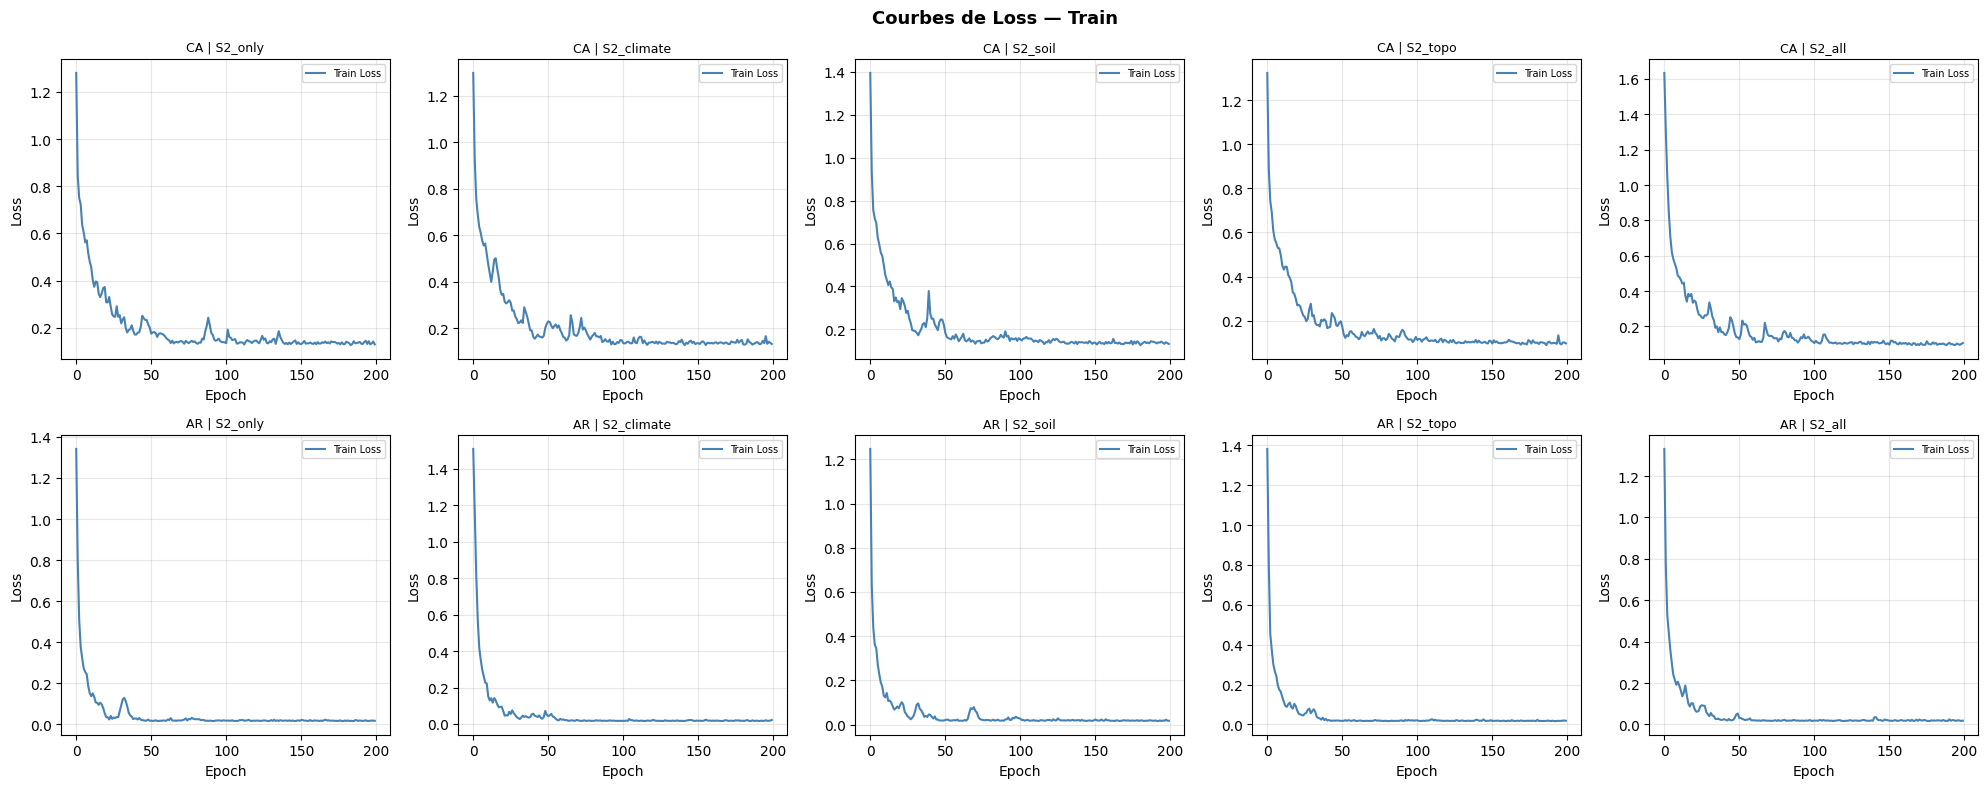

In [33]:
# ── Courbes de loss par région et configuration ──────────────────────────────

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for row, region in enumerate(['CA', 'AR']):
    for col, cfg in enumerate(BAND_DIMS.keys()):
        ax = axes[row, col]
        history = results[region][cfg]['history']
        ax.plot(history['loss'], label='Train Loss', color='steelblue')
        ax.set_title(f"{region} | {cfg}", fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle('Courbes de Loss — Train', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

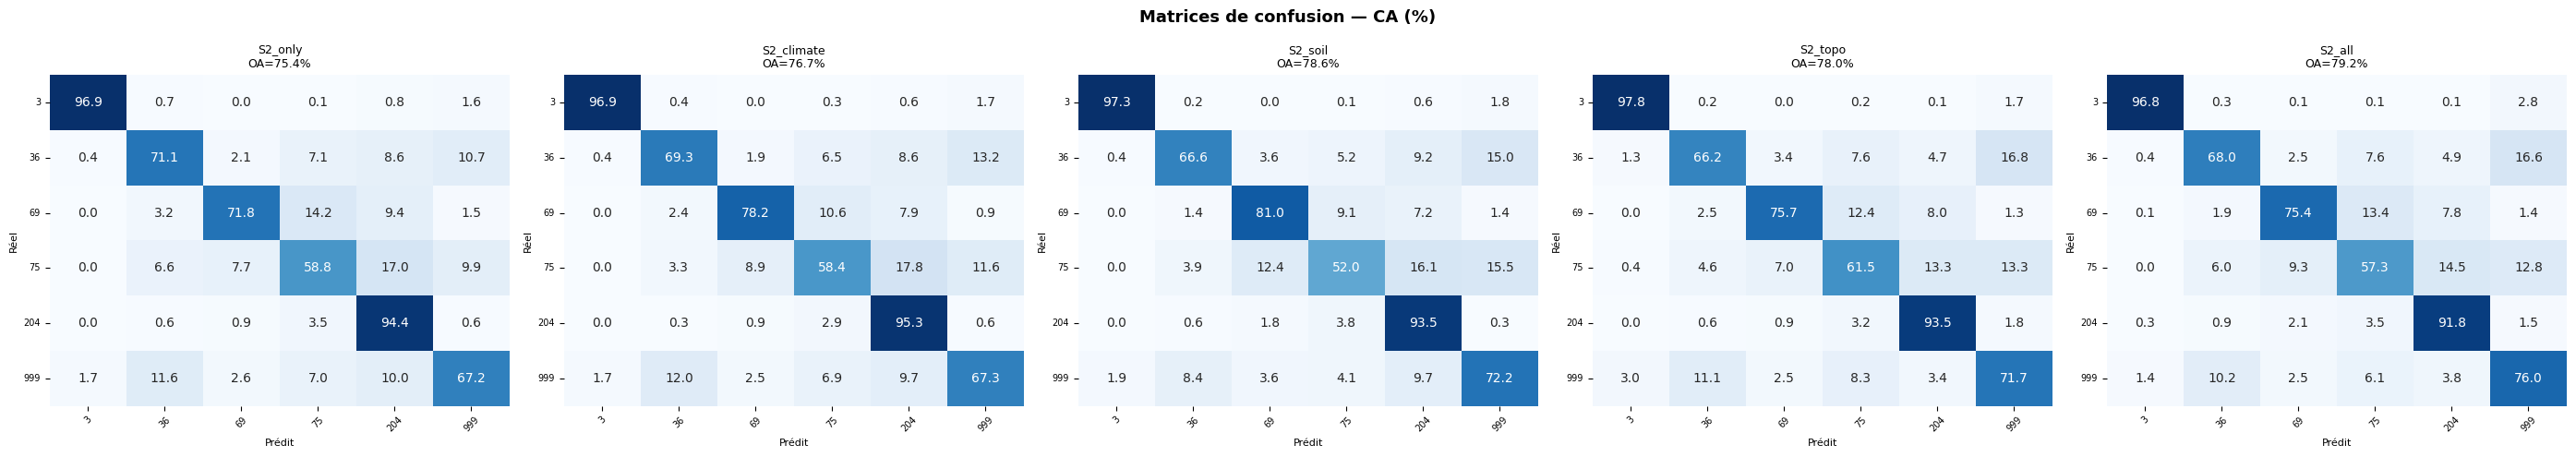

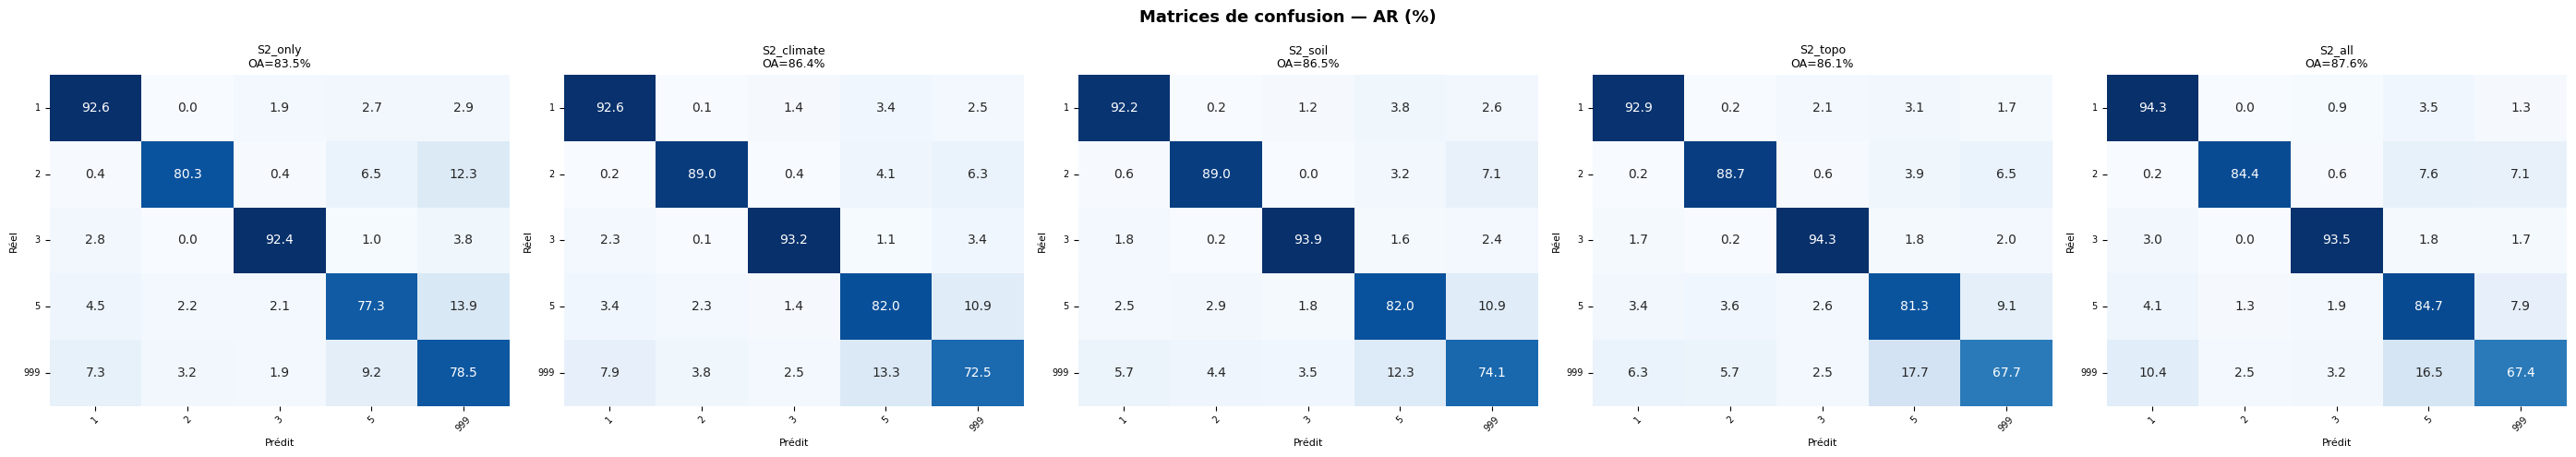

In [34]:
# ── Matrices de confusion par région et configuration ────────────────────────

for region, le in [('CA', CA_le), ('AR', AR_le)]:
    fig, axes = plt.subplots(1, 5, figsize=(28, 5))
    for col, cfg in enumerate(BAND_DIMS.keys()):
        ax   = axes[col]
        y_t  = results[region][cfg]['y_true']
        y_p  = results[region][cfg]['y_pred']
        cm   = confusion_matrix(y_t, y_p)
        cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        sns.heatmap(cm_n, annot=True, fmt='.1f', ax=ax,
                    cmap='Blues', xticklabels=le.classes_,
                    yticklabels=le.classes_, cbar=False)
        ax.set_title(f"{cfg}\nOA={results[region][cfg]['oa']:.1f}%", fontsize=9)
        ax.set_xlabel('Prédit', fontsize=8)
        ax.set_ylabel('Réel', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)

    plt.suptitle(f'Matrices de confusion — {region} (%)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()